# 模型选择与调优

在数据科学和机器学习中，模型的选择与调优是一个复杂且关键的过程。从线性回归到深度学习神经网络，模型种类繁多，每种模型都有其独特的优点和适用场景。因此，如何选择合适的模型并对其进行有效的调优，成为了数据科学家和机器学习工程师面临的重要问题。


## 模型选择
模型选择是数据科学和机器学习过程中的第一步。在选择模型时，我们需要考虑数据的性质、问题的复杂性和计算资源等多个因素。

- **数据性质：**数据的类型、分布和规模是影响模型选择的重要因素。例如，对于非线性关系的数据，线性回归模型可能无法提供满意的预测结果，而神经网络则可能表现出更好的性能。


- **问题复杂性：**问题的复杂性决定了所需模型的复杂度。对于简单的问题，如线性回归或分类，简单的模型（如逻辑回归）可能就足够了。然而，对于复杂的问题，如图像识别或自然语言处理，深度学习模型可能更加适合。


- **计算资源：**计算资源是限制模型选择的一个重要因素。深度学习模型通常需要大量的计算资源和时间来训练和预测。因此，在选择模型时，我们需要考虑可用的计算资源。


## 模型调优
模型调优是提升模型性能的关键步骤。在选择了合适的模型后，我们需要通过调整模型的参数（称为超参数）来优化模型的性能。

- **交叉验证：**交叉验证是一种常用的模型评估方法。它通过将数据集分成训练集和验证集（或测试集），在训练集上训练模型，并在验证集上评估模型的性能，从而避免过拟合和欠拟合的问题。常见的交叉验证方法包括K折交叉验证和留一交叉验证。


- **超参数调整：**超参数是模型训练前需要设置的参数，如学习率、批量大小、网络层数和神经元数量等。这些参数对模型的性能有显著影响。超参数调整通常通过网格搜索、随机搜索或贝叶斯优化等方法进行。


- **集成学习：**集成学习是一种通过结合多个模型的预测结果来提高整体性能的方法。常见的集成学习方法包括袋装（Bagging）、提升（Boosting）和堆叠（Stacking）等。这些方法通过减少模型的方差或偏差来提高预测的准确性。

## 为什么需要交叉验证？
在机器学习里，通常来说我们不能将全部用于数据训练模型，否则我们将没有数据集对该模型进行验证，从而评估我们的模型的预测效果。为了解决这一问题,我们会使用交叉验证来评估模型，目的是为了让被评估的模型更加准确可信！

## 什么是交叉验证(cross validation)
交叉验证：将拿到的训练数据，分为训练和验证集。以下图为例：将数据分成4份，其中一份作为验证集。然后经过4次(组)的测试，每次都更换不同的验证集。即得到5组模型的结果，取平均值作为最终结果。又称4折交叉验证。

### 交叉验证原理分析
我们之前知道数据分为训练集和测试集，但是为了让从训练得到模型结果更加准确。做以下处理

- 训练集：训练集+验证集
- 测试集：测试集

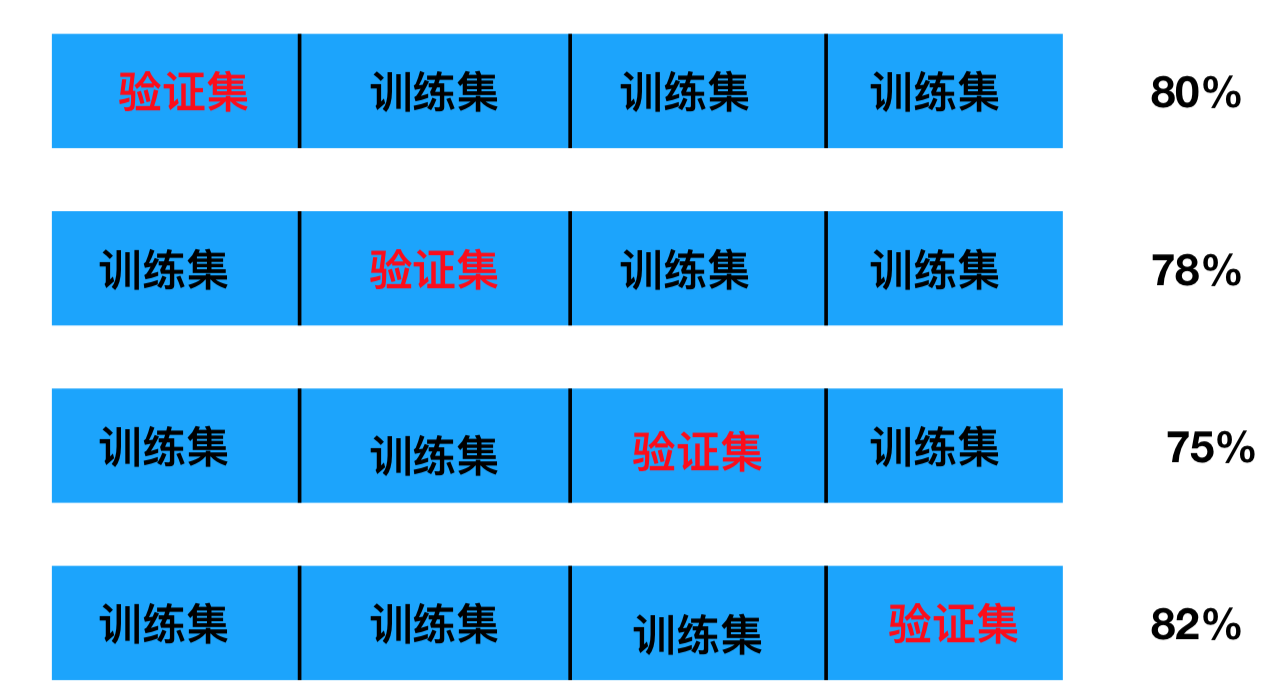

**问题：那么这个只是对于参数得出更好的结果，那么怎么选择或者调优参数呢？**

## 超参数搜索-网格搜索(Grid Search)

通常情况下，有很多参数是需要手动指定的（如k-近邻算法中的K值），这种叫超参数。但是手动过程繁杂，所以需要对模型预设几种超参数组合。每组超参数都采用交叉验证来进行评估。最后选出最优参数组合建立模型。

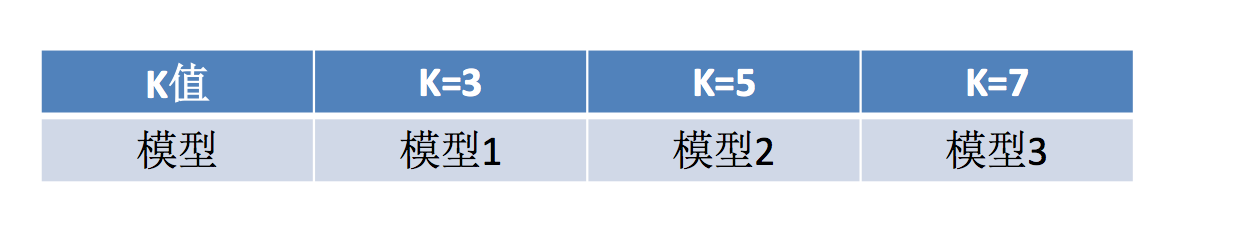

### 模型选择与调优
- sklearn.model_selection.GridSearchCV(estimator, param_grid=None,cv=None)
    - 对估计器的指定参数值进行详尽搜索
    - estimator：估计器对象
    - param_grid：估计器参数(dict){“n_neighbors”:[1,3,5]}
    - cv：指定几折交叉验证
    - fit：输入训练数据
    - score：准确率
    - 结果分析：
        - bestscore:在交叉验证中验证的最好结果_
        - bestestimator：最好的参数模型
        - cvresults:每次交叉验证后的验证集准确率结果和训练集准确率结果

In [26]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier  # K近邻算法

# 定义电影数据集
movies = [
    {"features": (3, 104), "label": "爱情片"},
    {"features": (2, 100), "label": "爱情片"},
    {"features": (1, 81), "label": "爱情片"},
    {"features": (101, 10), "label": "动作片"},
    {"features": (99, 5), "label": "动作片"},
    {"features": (98, 2), "label": "动作片"},
]

# Pandas 格式
movies_df = pd.DataFrame(movies)

# 2. 处理特征格式：将元组列表转为二维数组（sklearn要求）
X = np.array(movies_df["features"].tolist())  # 特征矩阵：6行2列
print(X)
y = movies_df["label"]  # 标签数组
print(y)

# 新电影的特征（需转为二维数组）
new_movie = np.array([[18, 90]])  # 注意：必须是二维，形状(1,2)

# 3. 初始化并训练KNN模型
knn = KNeighborsClassifier(n_neighbors=3, algorithm='auto')  # K值选3更合理（样本共6个）
knn.fit(X, y)  # 传入二维特征矩阵和一维标签  (训练)

# 4. 预测新电影类型
predicted_label = knn.predict(new_movie)
print(f"新电影的预测类型是: {predicted_label[0]}")  # predicted_label是数组，取第一个元素

[[  3 104]
 [  2 100]
 [  1  81]
 [101  10]
 [ 99   5]
 [ 98   2]]
0    爱情片
1    爱情片
2    爱情片
3    动作片
4    动作片
5    动作片
Name: label, dtype: object
新电影的预测类型是: 爱情片


In [32]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
import os

# 定义电影数据集
movies = [
    {"features": (3, 104), "label": "爱情片"},
    {"features": (2, 100), "label": "爱情片"},
    {"features": (1, 81), "label": "爱情片"},
    {"features": (3, 71), "label": "爱情片"},
    {"features": (6, 104), "label": "爱情片"},
    {"features": (4, 100), "label": "爱情片"},
    {"features": (7, 81), "label": "爱情片"},
    {"features": (6, 71), "label": "爱情片"},
    {"features": (101, 10), "label": "动作片"},
    {"features": (99, 5), "label": "动作片"},
    {"features": (98, 2), "label": "动作片"},
    {"features": (78, 6), "label": "动作片"},
    {"features": (111, 11), "label": "动作片"},
    {"features": (199, 10), "label": "动作片"},
    {"features": (98, 5), "label": "动作片"},
    {"features": (76, 1), "label": "动作片"}
]

# Pandas 格式
movies_df = pd.DataFrame(movies)

# 2. 处理特征格式：将元组列表转为二维数组（sklearn要求）
X = np.array(movies_df["features"].tolist())  # 特征矩阵：6行2列
y = movies_df["label"]  # 标签数组

new_movie = np.array([[18, 90]])

# 使用网格搜索和交叉验证找到合适的参数
knn = KNeighborsClassifier()

param = {"n_neighbors": [3, 5, 7]}

gc = GridSearchCV(knn, param_grid=param, cv=2)

gc.fit(X, y)

predicted_label = gc.predict(new_movie)
print(f"新电影的预测类型是: {predicted_label[0]}")  # predicted_label是数组，取第一个元素

# 训练验证集的结果
print("在交叉验证当中验证的最好结果：", gc.best_score_)
print("gc选择了的模型K值是：", gc.best_estimator_)
print("每次交叉验证的结果为：", gc.cv_results_)

新电影的预测类型是: 爱情片
在交叉验证当中验证的最好结果： 1.0
gc选择了的模型K值是： KNeighborsClassifier(n_neighbors=3)
每次交叉验证的结果为： {'mean_fit_time': array([0.00199211, 0.00099516, 0.00049829]), 'std_fit_time': array([9.98139381e-04, 1.90734863e-06, 4.98294830e-04]), 'mean_score_time': array([0.00149596, 0.00099826, 0.00049937]), 'std_score_time': array([4.99367714e-04, 4.29153442e-06, 4.99367714e-04]), 'param_n_neighbors': masked_array(data=[3, 5, 7],
             mask=[False, False, False],
       fill_value='?',
            dtype=object), 'params': [{'n_neighbors': 3}, {'n_neighbors': 5}, {'n_neighbors': 7}], 'split0_test_score': array([1., 1., 1.]), 'split1_test_score': array([1., 1., 1.]), 'mean_test_score': array([1., 1., 1.]), 'std_test_score': array([0., 0., 0.]), 'rank_test_score': array([1, 1, 1])}
